# Week 12 - Milestone Two week

# 1. Lesson: no lesson this week.  Milestone Two is due!

# 2. Weekly graph question

Suppose you plot the number visitors to a museum over the seven days of a week; then again the following week.  Can you suggest the advantages and disadvantages of the following two ways of presenting the data?

In [8]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Text(0, 0.5, 'Number of visitors')

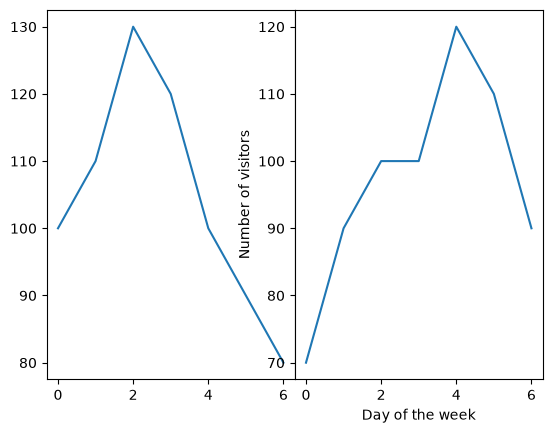

In [9]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Text(0, 0.5, 'Number of visitors')

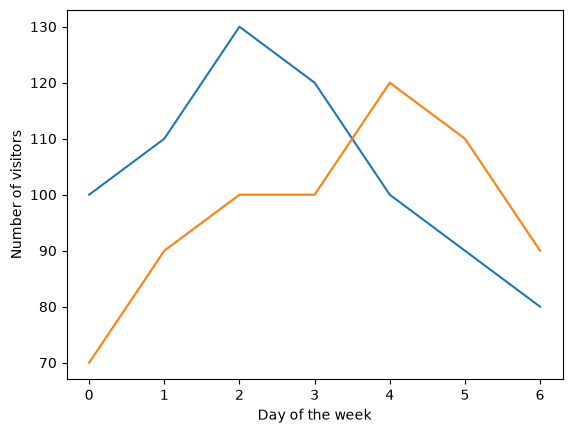

In [10]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Side-by-side subplots (two separate panels):
This avoids visual clutter — each week's shape is easy to read on its own, and since the panels sit flush against each other (wspace=0), you can still eyeball relative height across the boundary. The downside is that direct day-by-day comparison is harder: your eye has to jump between two separate x-axes rather than reading two points at the same x-position. It's also only trustworthy if both panels share the same y-axis scale — the code above doesn't set sharey=True, so matplotlib will autoscale each subplot independently, and two visually similar-looking lines could actually represent very different visitor counts. That's a real trap: touching panels visually imply "same scale," but nothing in the code guarantees it.

Overlaid line plot (both series on one axes):
This makes direct comparison easy — for any given day, you can see both weeks' values at a glance and immediately read off which week was higher and by how much, since they share one x-axis and one y-axis by construction. The tradeoff is clutter: if the two lines cross often or track closely, they can be hard to disentangle visually, and without a legend (missing in the code) there's no way to tell which color corresponds to which week — that's a real gap in the second snippet that should be fixed with plt.legend(["Week 1", "Week 2"]).
In short: use side-by-side when you care about each week's individual pattern and want to avoid overlap; use the overlay when the point is to compare the two weeks directly, provided you add a legend and don't let overlapping lines obscure the trends.

# 3. Working on your datasets

This week, you can work on Milestone Two rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 187-205 of the Storytelling With Data book as best you can. (Chapter Eight). You do not have to get the exact data values right, just the overall look and feel.

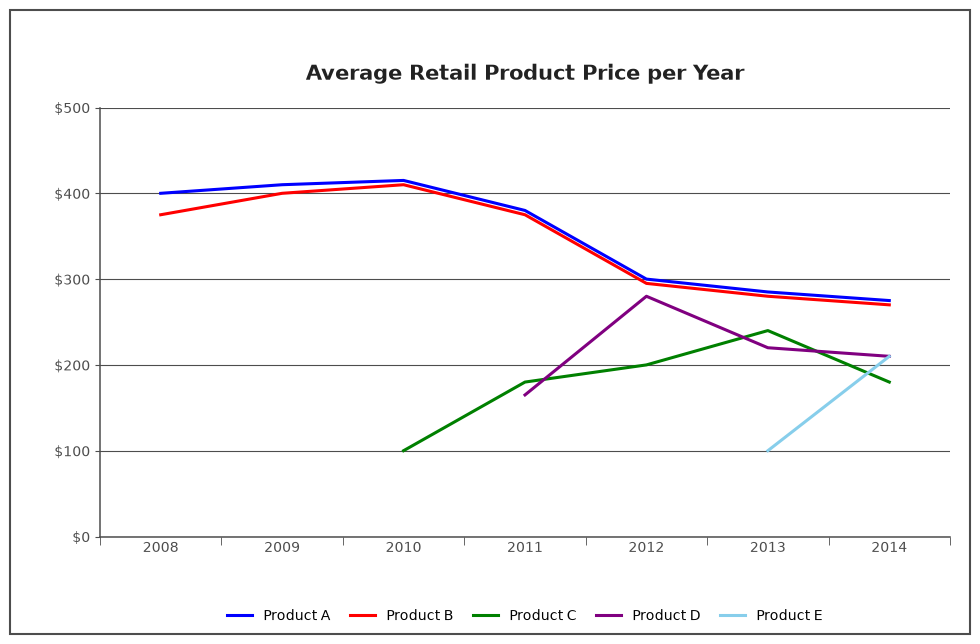

In [11]:
# Line Graph (Figure 8.5 on pg. 193)

# Data
years_full = [2008, 2009, 2010, 2011, 2012, 2013, 2014]

series = {
    'Product A': {'years': [2008, 2009, 2010, 2011, 2012, 2013, 2014],
                  'values': [400, 410, 415, 380, 300, 285, 275],
                  'color': 'blue'},
    'Product B': {'years': [2008, 2009, 2010, 2011, 2012, 2013, 2014],
                  'values': [375, 400, 410, 375, 295, 280, 270],
                  'color': 'red'},
    'Product C': {'years': [2010, 2011, 2012, 2013, 2014],
                  'values': [100, 180, 200, 240, 180],
                  'color': 'green'},
    'Product D': {'years': [2011, 2012, 2013, 2014],
                  'values': [165, 280, 220, 210],
                  'color': 'purple'},
    'Product E': {'years': [2013, 2014],
                  'values': [100, 210],
                  'color': 'skyblue'},
}

dark_grey = '#4d4d4d'

# Figure + axes (axes leaves room at the top for the title and at the bottom for the legend)
fig = plt.figure(figsize=(10, 6.5), facecolor='white')
ax = fig.add_axes([0.11, 0.17, 0.85, 0.66])

for name, d in series.items():
    ax.plot(d['years'], d['values'], color=d['color'], linewidth=2.2, label=name)

# Y-axis: $0-$500 in $100 increments, with horizontal gridlines
ax.set_ylim(0, 500)
ax.set_yticks(range(0, 501, 100))
ax.set_yticklabels([f'${v}' for v in range(0, 501, 100)])
ax.yaxis.grid(True, color=dark_grey, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# X-axis: year labels centered, tick marks between the years
ax.set_xlim(2007.5, 2014.5)
ax.set_xticks(years_full)                      # label positions (no visible tick marks)
ax.set_xticklabels(years_full)
ax.tick_params(axis='x', which='major', length=0, colors=dark_grey)

between_ticks = [y + 0.5 for y in years_full]  # includes one after the last year (2014.5)
between_ticks = [years_full[0] - 0.5] + between_ticks
ax.set_xticks(between_ticks, minor=True)
ax.tick_params(axis='x', which='minor', length=6, color=dark_grey)

ax.tick_params(axis='y', colors=dark_grey)

# Spines: only left & bottom, dark grey
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(dark_grey)
ax.spines['bottom'].set_color(dark_grey)
ax.spines['left'].set_linewidth(1.1)
ax.spines['bottom'].set_linewidth(1.1)

# Title
ax.set_title('Average Retail Product Price per Year', fontsize=15, fontweight='bold',
              color='#222222', pad=20)

# Legend: single row, colored line swatches + product names, below the chart
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=5,
          frameon=False, handlelength=1.8, columnspacing=1.4, fontsize=10)

# Outer dark-grey box enclosing title, legend, and chart
outer = patches.Rectangle((0.02, 0.02), 0.96, 0.96, transform=fig.transFigure,
                           facecolor='none', edgecolor=dark_grey, linewidth=1.5)
fig.add_artist(outer)

plt.show()